# 01 — Análisis Exploratorio de Datos (EDA)

**Caso de uso:** Predicción de Diagnóstico de Cáncer  
**Asignatura:** Inteligencia Artificial — UAX 2025/2026  
**Autor:** Álvaro Santamaría Antón

## Objetivos del EDA

1. Inspeccionar cada CSV por separado (tipos, nulos, rangos, distribuciones)
2. Verificar la integridad del join por `paciente_id` entre las 6 colecciones
3. Calcular prevalencia de la variable objetivo y razón de desbalance
4. Detectar variables con fuga de datos (data leakage)
5. Análisis univariante y bivariante de las variables candidatas
6. Producir una **tabla de decisiones final** (incluir / excluir / transformar)

## Imports y configuración

In [1]:
# === Imports ===
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Configuración global ===
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

RANDOM_STATE = 42

# === Rutas del proyecto ===
PROJECT_ROOT = Path.cwd().parent  # estamos en notebooks/, subimos un nivel
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data dir : {RAW_DIR}  (existe: {RAW_DIR.exists()})")
print(f"Figures dir  : {FIGURES_DIR}  (existe: {FIGURES_DIR.exists()})")

Project root : c:\Users\alvar\Desktop\proyecto-cancer-ia
Raw data dir : c:\Users\alvar\Desktop\proyecto-cancer-ia\data\raw  (existe: True)
Figures dir  : c:\Users\alvar\Desktop\proyecto-cancer-ia\reports\figures  (existe: True)


## Función robusta de carga de los CSV

In [2]:
def load_csv(file_name: str) -> pd.DataFrame:
    """
    Carga un CSV del dataset.
    
    Maneja dos particularidades detectadas:
    - Encoding UTF-8 con BOM en 5 de los 6 CSVs (utf-8-sig limpia el BOM si existe).
    - El CSV 04 (ECONOMICOS) usa coma como separador decimal en lugar de punto.
    """
    path = RAW_DIR / file_name
    
    # Caso especial: el CSV 04 usa coma decimal
    if "04_ECONOMICOS" in file_name:
        df = pd.read_csv(path, encoding="utf-8-sig", decimal=",")
    else:
        df = pd.read_csv(path, encoding="utf-8-sig")
    
    return df


# Cargamos las 6 colecciones
df_bio   = load_csv("CASOCANCER_01_BIOQUIMICOS.csv")
df_clin  = load_csv("CASOCANCER_02_CLINICOS.csv")
df_gen   = load_csv("CASOCANCER_03_GENETICOS.csv")
df_eco   = load_csv("CASOCANCER_04_ECONOMICOS.csv")
df_hab   = load_csv("CASOCANCER_05_GENERALES.csv")       # hábitos de vida
df_demo  = load_csv("CASOCANCER_06_SOCIODEMOGRAFICOS.csv")

# Diccionario para iterar cómodamente
collections = {
    "01_bioquimicos":      df_bio,
    "02_clinicos":         df_clin,
    "03_geneticos":        df_gen,
    "04_economicos":       df_eco,
    "05_habitos":          df_hab,
    "06_sociodemograficos": df_demo,
}

# Resumen rápido
print("Carga completada. Dimensiones de cada colección:\n")
for name, df in collections.items():
    print(f"  {name:25s} → {df.shape[0]:>6} filas × {df.shape[1]:>2} columnas")

Carga completada. Dimensiones de cada colección:

  01_bioquimicos            →  50001 filas ×  8 columnas
  02_clinicos               →  50001 filas ×  8 columnas
  03_geneticos              →  50001 filas ×  8 columnas
  04_economicos             →  50001 filas ×  6 columnas
  05_habitos                →  50001 filas ×  5 columnas
  06_sociodemograficos      →  50001 filas ×  8 columnas


## Inspección de cabeceras

In [3]:
# Ver las primeras filas de cada colección
for name, df in collections.items():
    print(f"\n{'=' * 60}")
    print(f"  {name.upper()}")
    print(f"{'=' * 60}")
    display(df.head(3))


  01_BIOQUIMICOS


,paciente_id,glucosa,colesterol,trigliceridos,hemoglobina,leucocitos,plaquetas,creatinina
0,P1000000,94.6600,205.3200,130.3100,16.6200,10.0800,252.4600,0.8400
1,P1000001,103.9400,235.1700,149.6500,13.0900,7.2100,171.3200,0.8100
2,P1000002,131.3400,138.4200,166.9500,15.3200,6.1500,331.4800,0.9300



  02_CLINICOS


,paciente_id,diabetes,hipertension,obesidad,cancer,enfermedad_cardiaca,asma,epoc
0,P1000000,0,0,1,0,0,0,0
1,P1000001,0,0,1,0,0,0,0
2,P1000002,1,1,0,1,0,1,0



  03_GENETICOS


...

,paciente_id,tipo_seguro,coste_total,coste_farmaco,num_ingresos,dias_hospital
0,P1000000,Publico,"6,377.0300","2,502.5000",1,17
1,P1000001,Publico,"4,333.1100","1,571.9800",0,2
2,P1000002,Publico,"55,907.7100","20,656.2200",5,100



  05_HABITOS


,paciente_id,fumador,alcohol,actividad_fisica,vive
0,P1000000,0,1,Moderada,1
1,P1000001,0,1,Moderada,1
2,P1000002,0,1,Moderada,1



  06_SOCIODEMOGRAFICOS


,paciente_id,edad,nivel_educativo,nivel_ingresos,zona,estado_civil,num_hijos,distancia_hospital_km
0,P1000000,53,Secundaria,Medio,Urbana,Casado,2,25.6000
1,P1000001,66,Secundaria,Alto,Urbana,Divorciado,0,15.2000
2,P1000002,33,Secundaria,Bajo,Urbana,Casado,3,43.7000


## Tipos de datos y nulos

In [4]:
# Tipos de datos y nulos por colección
for name, df in collections.items():
    print(f"\n{'=' * 60}")
    print(f"  {name.upper()}")
    print(f"{'=' * 60}")
    print(f"Shape: {df.shape}")
    print(f"\nTipos y nulos:")
    
    info = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_nulos": df.isnull().sum(),
        "%_nulos": (df.isnull().sum() / len(df) * 100).round(2),
        "n_unicos": df.nunique(),
    })
    print(info)


  01_BIOQUIMICOS
Shape: (50001, 8)

Tipos y nulos:
                 dtype  n_nulos  %_nulos  n_unicos
paciente_id        str        0   0.0000     50001
glucosa        float64        0   0.0000      8773
colesterol     float64        0   0.0000     13242
trigliceridos  float64        0   0.0000     16571
hemoglobina    float64        0   0.0000       912
leucocitos     float64        0   0.0000      1123
plaquetas      float64        0   0.0000     19681
creatinina     float64        0   0.0000       161

  02_CLINICOS
Shape: (50001, 8)

Tipos y nulos:
                     dtype  n_nulos  %_nulos  n_unicos
paciente_id            str        0   0.0000     50001
diabetes             int64        0   0.0000         2
hipertension         int64        0   0.0000         2
obesidad             int64        0   0.0000         2
cancer               int64        0   0.0000         2
enfermedad_cardiaca  int64        0   0.0000         2
asma                 int64        0   0.0000         2


## Estadísticos descriptivos de variables numéricas

In [5]:
# Describe de las variables numéricas de cada colección
for name, df in collections.items():
    print(f"\n{'=' * 60}")
    print(f"  {name.upper()}  —  Estadísticos numéricos")
    print(f"{'=' * 60}")
    
    # Excluimos paciente_id porque es identificador
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numeric_cols) == 0:
        print("  (No hay columnas numéricas)")
        continue
    
    display(df[numeric_cols].describe().T.round(3))


  01_BIOQUIMICOS  —  Estadísticos numéricos


,count,mean,std,min,25%,50%,75%,max
glucosa,"50,001.0000",102.1920,19.1210,55.0000,88.7300,101.7800,115.2500,179.2300
colesterol,"50,001.0000",193.6610,32.4590,120.0000,171.3100,193.3000,215.3900,320.0000
trigliceridos,"50,001.0000",156.2300,42.9470,50.0000,126.4300,155.4100,185.2100,321.6800
hemoglobina,"50,001.0000",13.9260,1.5300,8.0000,12.9000,13.9300,14.9600,18.0000
leucocitos,"50,001.0000",7.1510,1.8570,2.0000,5.8900,7.1400,8.4000,15.0800
plaquetas,"50,001.0000",254.9710,54.6590,100.0000,218.1200,254.9600,291.8000,489.7900
creatinina,"50,001.0000",1.0000,0.2500,0.3500,0.8300,1.0000,1.1700,2.1000



  02_CLINICOS  —  Estadísticos numéricos


,count,mean,std,min,25%,50%,75%,max
diabetes,"50,001.0000",0.3450,0.4750,0.0000,0.0000,0.0000,1.0000,1.0000
hipertension,"50,001.0000",0.4430,0.4970,0.0000,0.0000,0.0000,1.0000,1.0000
obesidad,"50,001.0000",0.3540,0.4780,0.0000,0.0000,0.0000,1.0000,1.0000
cancer,"50,001.0000",0.1930,0.3950,0.0000,0.0000,0.0000,0.0000,1.0000
enfermedad_cardiaca,"50,001.0000",0.1660,0.3720,0.0000,0.0000,0.0000,0.0000,1.0000
asma,"50,001.0000",0.0820,0.2740,0.0000,0.0000,0.0000,0.0000,1.0000
epoc,"50,001.0000",0.0920,0.2890,0.0000,0.0000,0.0000,0.0000,1.0000



  03_GENETICOS  —  Estadísticos numéricos


...

,count,mean,std,min,25%,50%,75%,max
coste_total,"50,001.0000","15,170.9130","16,309.7490",500.0000,"6,013.3400","9,235.0400","13,833.4100","102,256.2900"
coste_farmaco,"50,001.0000","4,930.0270","5,532.5150",100.0700,"1,825.0700","2,915.7300","4,786.3300","41,932.1400"
num_ingresos,"50,001.0000",0.8800,1.2290,0.0000,0.0000,0.0000,1.0000,9.0000
dias_hospital,"50,001.0000",24.9130,27.5240,0.0000,9.0000,15.0000,25.0000,181.0000



  05_HABITOS  —  Estadísticos numéricos


,count,mean,std,min,25%,50%,75%,max
fumador,"50,001.0000",0.3800,0.4850,0.0000,0.0000,0.0000,1.0000,1.0000
alcohol,"50,001.0000",1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
vive,"50,001.0000",0.7380,0.4390,0.0000,0.0000,1.0000,1.0000,1.0000



  06_SOCIODEMOGRAFICOS  —  Estadísticos numéricos


,count,mean,std,min,25%,50%,75%,max
edad,"50,001.0000",54.4310,14.7840,20.0000,44.0000,54.0000,65.0000,90.0000
num_hijos,"50,001.0000",1.4970,1.2250,0.0000,1.0000,1.0000,2.0000,8.0000
distancia_hospital_km,"50,001.0000",24.8620,24.9520,0.5000,7.1000,17.1000,34.4000,250.0000


## Variables categóricas (conteos y cardinalidad)

In [6]:
# Análisis de variables categóricas (object) en cada colección
for name, df in collections.items():
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    # Excluimos paciente_id
    cat_cols = [c for c in cat_cols if c != "paciente_id"]
    
    if len(cat_cols) == 0:
        continue
    
    print(f"\n{'=' * 60}")
    print(f"  {name.upper()}  —  Variables categóricas")
    print(f"{'=' * 60}")
    
    for col in cat_cols:
        counts = df[col].value_counts(dropna=False)
        pct = (counts / len(df) * 100).round(2)
        summary = pd.DataFrame({"n": counts, "%": pct})
        print(f"\n  {col}:")
        print(summary.to_string())


  04_ECONOMICOS  —  Variables categóricas

  tipo_seguro:
                 n       %
tipo_seguro               
Publico      28106 56.2100
Privado      11943 23.8900
Mixto         9952 19.9000

  05_HABITOS  —  Variables categóricas

  actividad_fisica:
                      n       %
actividad_fisica               
Baja              22569 45.1400
Moderada          17392 34.7800
Alta              10040 20.0800

  06_SOCIODEMOGRAFICOS  —  Variables categóricas

  nivel_educativo:
                     n       %
nivel_educativo               
Secundaria       19931 39.8600
Primaria         12578 25.1600
Universitario    12383 24.7700
Sin estudios      5109 10.2200

  nivel_ingresos:
                    n       %
nivel_ingresos               
Medio           19948 39.9000
Bajo            14198 28.4000
Alto             9880 19.7600
Muy bajo         5975 11.9500

  zona:
                n       %
zona                     
Urbana      27408 54.8100
Semiurbana  12649 25.3000
Rural        9944

## Comparar conjuntos de IDs entre colecciones

In [7]:
# Tomamos los conjuntos de paciente_id de cada colección
sets_ids = {name: set(df["paciente_id"]) for name, df in collections.items()}

# 1. Verificar tamaños
print("Tamaño del conjunto de IDs por colección:")
for name, s in sets_ids.items():
    print(f"  {name:25s} → {len(s):>6} IDs únicos")

# 2. Comparar si todas las colecciones tienen exactamente los mismos IDs
ids_bio = sets_ids["01_bioquimicos"]
todas_iguales = all(s == ids_bio for s in sets_ids.values())

print(f"\n¿Las 6 colecciones tienen exactamente los mismos IDs?  →  {todas_iguales}")

# 3. Si no fueran iguales, ver qué falta dónde
if not todas_iguales:
    print("\n⚠️  Diferencias detectadas:")
    for name, s in sets_ids.items():
        faltan_aqui = ids_bio - s
        sobran_aqui = s - ids_bio
        if faltan_aqui or sobran_aqui:
            print(f"  {name}: faltan {len(faltan_aqui)}, sobran {len(sobran_aqui)}")
else:
    # 4. Verificación adicional: ¿hay algún paciente_id duplicado en alguna colección?
    print("\nVerificando duplicados internos en cada colección:")
    for name, df in collections.items():
        n_dup = df["paciente_id"].duplicated().sum()
        print(f"  {name:25s} → duplicados: {n_dup}")

Tamaño del conjunto de IDs por colección:
  01_bioquimicos            →  50001 IDs únicos
  02_clinicos               →  50001 IDs únicos
  03_geneticos              →  50001 IDs únicos
  04_economicos             →  50001 IDs únicos
  05_habitos                →  50001 IDs únicos
  06_sociodemograficos      →  50001 IDs únicos

¿Las 6 colecciones tienen exactamente los mismos IDs?  →  True

Verificando duplicados internos en cada colección:
  01_bioquimicos            → duplicados: 0
  02_clinicos               → duplicados: 0
  03_geneticos              → duplicados: 0
  04_economicos             → duplicados: 0
  05_habitos                → duplicados: 0
  06_sociodemograficos      → duplicados: 0


## Construir el df_master (merge de las 6 colecciones)

In [8]:
# Hacemos el merge progresivo de las 6 colecciones por paciente_id
# Usamos how="inner" para quedarnos solo con pacientes presentes en TODAS las colecciones
# (si la celda anterior confirmó que todos coinciden, "inner" e "outer" dan lo mismo)

df_master = df_bio.copy()
for name, df in [("clinicos", df_clin),
                 ("geneticos", df_gen),
                 ("economicos", df_eco),
                 ("habitos", df_hab),
                 ("sociodemograficos", df_demo)]:
    n_antes = len(df_master)
    df_master = df_master.merge(df, on="paciente_id", how="inner")
    n_despues = len(df_master)
    print(f"  Tras merge con {name:20s} → {n_despues:>6} filas (delta: {n_despues - n_antes:+d})")

print(f"\nDimensiones finales del df_master: {df_master.shape}")
print(f"  Filas:    {df_master.shape[0]}")
print(f"  Columnas: {df_master.shape[1]}")

# Verificación final: ningún paciente_id duplicado y ningún nulo introducido por el merge
print(f"\nDuplicados en paciente_id: {df_master['paciente_id'].duplicated().sum()}")
print(f"Nulos totales en df_master: {df_master.isnull().sum().sum()}")

  Tras merge con clinicos             →  50001 filas (delta: +0)
  Tras merge con geneticos            →  50001 filas (delta: +0)
  Tras merge con economicos           →  50001 filas (delta: +0)
  Tras merge con habitos              →  50001 filas (delta: +0)
  Tras merge con sociodemograficos    →  50001 filas (delta: +0)

Dimensiones finales del df_master: (50001, 38)
  Filas:    50001
  Columnas: 38

Duplicados en paciente_id: 0
Nulos totales en df_master: 0


## Vista rápida del df_master

In [9]:
print(f"Columnas del df_master ({len(df_master.columns)} en total):\n")
for i, col in enumerate(df_master.columns, 1):
    print(f"  {i:>2}. {col:30s} ({df_master[col].dtype})")

print("\nMuestra (3 primeras filas):")
display(df_master.head(3))

Columnas del df_master (38 en total):

   1. paciente_id                    (str)
   2. glucosa                        (float64)
   3. colesterol                     (float64)
   4. trigliceridos                  (float64)
   5. hemoglobina                    (float64)
   6. leucocitos                     (float64)
   7. plaquetas                      (float64)
   8. creatinina                     (float64)
   9. diabetes                       (int64)
  10. hipertension                   (int64)
  11. obesidad                       (int64)
  12. cancer                         (int64)
  13. enfermedad_cardiaca            (int64)
  14. asma                           (int64)
  15. epoc                           (int64)
  16. mut_BRCA1                      (int64)
  17. mut_TP53                       (int64)
  18. mut_EGFR                       (int64)
  19. mut_KRAS                       (int64)
  20. mut_PIK3CA                     (int64)
  21. mut_ALK                        (int64)
  22

,paciente_id,glucosa,colesterol,trigliceridos,hemoglobina,leucocitos,plaquetas,creatinina,diabetes,hipertension,obesidad,cancer,enfermedad_cardiaca,asma,epoc,mut_BRCA1,mut_TP53,mut_EGFR,mut_KRAS,mut_PIK3CA,mut_ALK,mut_BRAF,tipo_seguro,coste_total,coste_farmaco,num_ingresos,dias_hospital,fumador,alcohol,actividad_fisica,vive,edad,nivel_educativo,nivel_ingresos,zona,estado_civil,num_hijos,distancia_hospital_km
0,P1000000,94.6600,205.3200,130.3100,16.6200,10.0800,252.4600,0.8400,0,0,1,0,0,0,0,0,0,0,0,0,0,0,Publico,"6,377.0300","2,502.5000",1,17,0,1,Moderada,1,53,Secundaria,Medio,Urbana,Casado,2,25.6000
1,P1000001,103.9400,235.1700,149.6500,13.0900,7.2100,171.3200,0.8100,0,0,1,0,0,0,0,0,0,0,0,0,0,0,Publico,"4,333.1100","1,571.9800",0,2,0,1,Moderada,1,66,Secundaria,Alto,Urbana,Divorciado,0,15.2000
2,P1000002,131.3400,138.4200,166.9500,15.3200,6.1500,331.4800,0.9300,1,1,0,1,0,1,0,1,0,0,0,0,0,0,Publico,"55,907.7100","20,656.2200",5,100,0,1,Moderada,1,33,Secundaria,Bajo,Urbana,Casado,3,43.7000


## Análisis profundo de la variable objetivo

  VARIABLE OBJETIVO: cancer

  Total de pacientes:         50,001
  Negativos (sin cáncer):     40,357  (80.71%)
  Positivos (con cáncer):      9,644  (19.29%)

  Prevalencia:               0.1929  (19.29%)
  Razón de desbalance:       4.18 : 1

  Esperado por la metadata:  ~19% (prevalencia), ~4.26 : 1 (ratio)


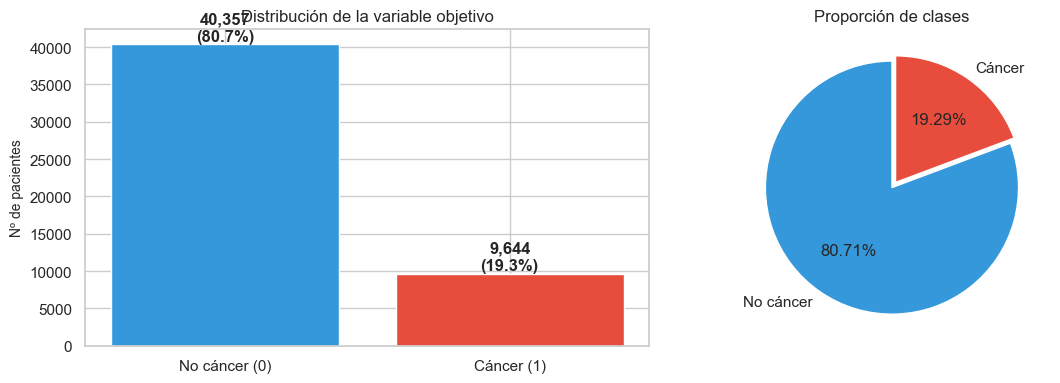


Gráfico guardado en: c:\Users\alvar\Desktop\proyecto-cancer-ia\reports\figures\01_distribucion_target.png


In [10]:
# === Variable objetivo: cancer ===
print("=" * 60)
print("  VARIABLE OBJETIVO: cancer")
print("=" * 60)

n_total = len(df_master)
n_pos = (df_master["cancer"] == 1).sum()
n_neg = (df_master["cancer"] == 0).sum()

prevalencia = n_pos / n_total
ratio_desbalance = n_neg / n_pos

print(f"\n  Total de pacientes:        {n_total:>7,}")
print(f"  Negativos (sin cáncer):    {n_neg:>7,}  ({n_neg/n_total*100:.2f}%)")
print(f"  Positivos (con cáncer):    {n_pos:>7,}  ({n_pos/n_total*100:.2f}%)")
print(f"\n  Prevalencia:               {prevalencia:.4f}  ({prevalencia*100:.2f}%)")
print(f"  Razón de desbalance:       {ratio_desbalance:.2f} : 1")
print(f"\n  Esperado por la metadata:  ~19% (prevalencia), ~4.26 : 1 (ratio)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
counts = df_master["cancer"].value_counts().sort_index()
axes[0].bar(["No cáncer (0)", "Cáncer (1)"], counts.values,
            color=["#3498db", "#e74c3c"])
axes[0].set_title("Distribución de la variable objetivo")
axes[0].set_ylabel("Nº de pacientes")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/n_total*100:.1f}%)",
                 ha="center", fontweight="bold")

# Gráfico de tarta
axes[1].pie(counts.values, labels=["No cáncer", "Cáncer"],
            autopct="%1.2f%%", colors=["#3498db", "#e74c3c"],
            startangle=90, explode=(0, 0.05))
axes[1].set_title("Proporción de clases")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distribucion_target.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nGráfico guardado en: {FIGURES_DIR / '01_distribucion_target.png'}")

## Detección visual de leakage en variables económicas

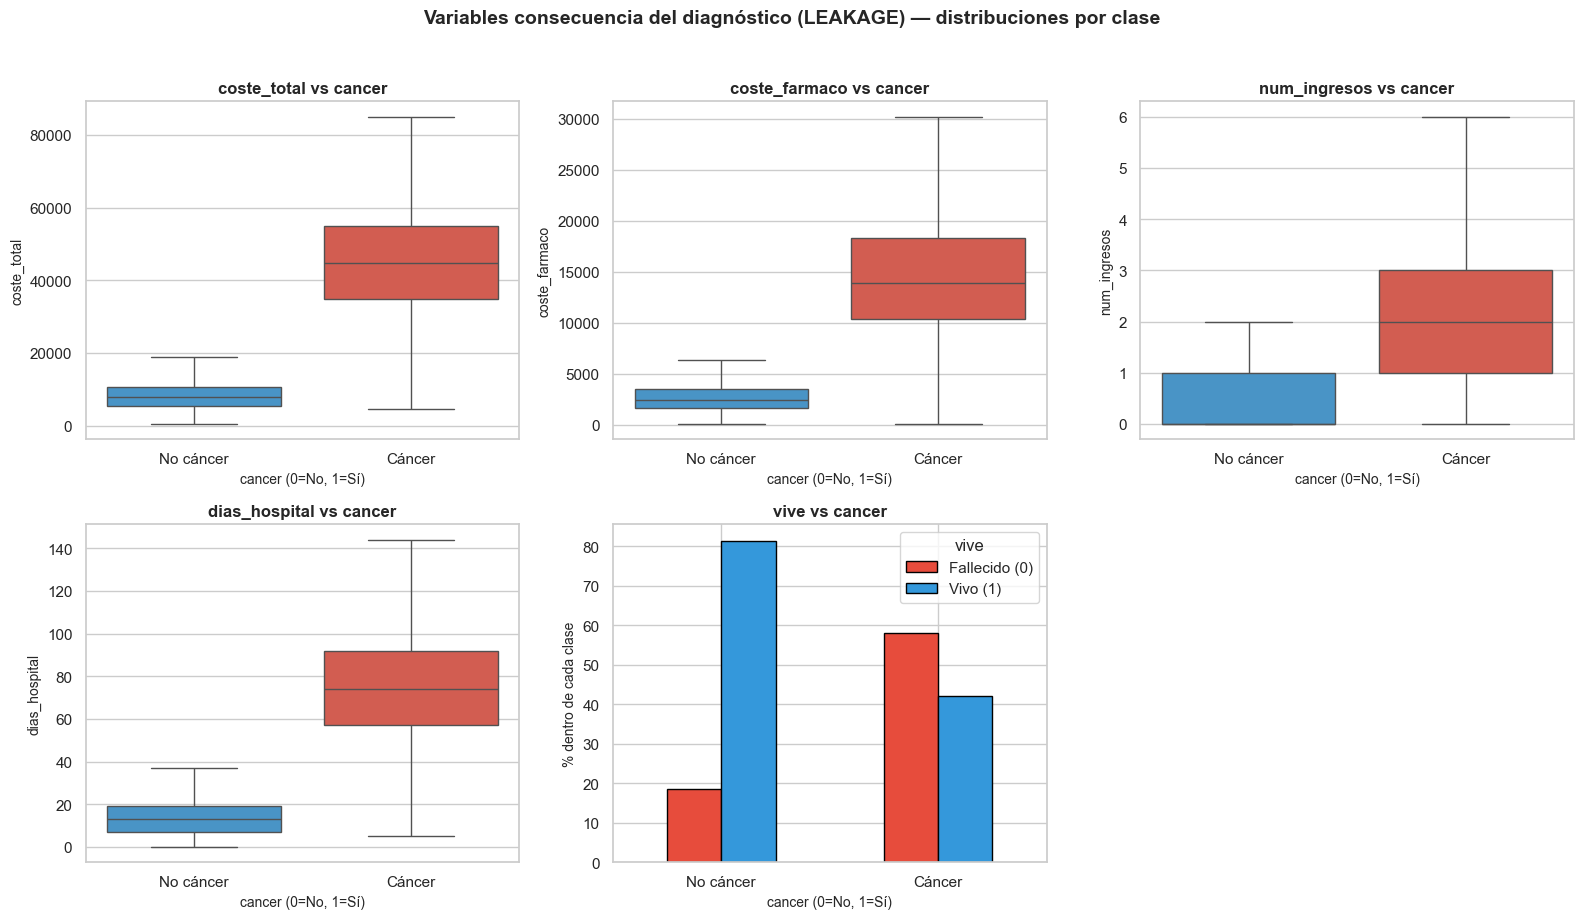


  RESUMEN NUMÉRICO: medianas por clase
  coste_total        → No cáncer:    8,029.3   Cáncer:   44,824.0   ratio: 5.58x
  coste_farmaco      → No cáncer:    2,479.9   Cáncer:   13,964.0   ratio: 5.63x
  num_ingresos       → No cáncer:        0.0   Cáncer:        2.0   ratio: infx
  dias_hospital      → No cáncer:       13.0   Cáncer:       74.0   ratio: 5.69x
  vive (% vivos)     → No cáncer:      81.5%   Cáncer:      42.0%   diff: +39.5 pp


In [13]:
# === Variables sospechosas de leakage según la metadata ===
leakage_vars = ["coste_total", "coste_farmaco", "num_ingresos", "dias_hospital", "vive"]

# Paleta con claves string (seaborn 0.13+)
palette_target = {"0": "#3498db", "1": "#e74c3c"}

# Creamos una columna auxiliar de cancer como string para los plots
df_master["cancer_str"] = df_master["cancer"].astype(str)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(leakage_vars):
    ax = axes[i]
    
    if var == "vive":
        # Para variable binaria: barras
        ct = pd.crosstab(df_master["cancer"], df_master[var], normalize="index") * 100
        ct.plot(kind="bar", ax=ax, color=["#e74c3c", "#3498db"], edgecolor="black")
        ax.set_title(f"{var} vs cancer", fontweight="bold")
        ax.set_xlabel("cancer (0=No, 1=Sí)")
        ax.set_ylabel("% dentro de cada clase")
        ax.legend(["Fallecido (0)", "Vivo (1)"], title=var)
        ax.set_xticklabels(["No cáncer", "Cáncer"], rotation=0)
    else:
        # Para continuas: boxplot (sintaxis seaborn 0.13+)
        sns.boxplot(data=df_master, x="cancer_str", y=var, hue="cancer_str",
                    palette=palette_target, showfliers=False, ax=ax, legend=False)
        ax.set_title(f"{var} vs cancer", fontweight="bold")
        ax.set_xlabel("cancer (0=No, 1=Sí)")
        ax.set_xticklabels(["No cáncer", "Cáncer"])

# Ocultamos el sexto subplot vacío
axes[5].axis("off")

plt.suptitle("Variables consecuencia del diagnóstico (LEAKAGE) — distribuciones por clase",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_leakage_visual.png", dpi=120, bbox_inches="tight")
plt.show()

# Tabla numérica resumen del impacto
print("\n" + "=" * 70)
print("  RESUMEN NUMÉRICO: medianas por clase")
print("=" * 70)

for var in ["coste_total", "coste_farmaco", "num_ingresos", "dias_hospital"]:
    med_neg = df_master.loc[df_master["cancer"] == 0, var].median()
    med_pos = df_master.loc[df_master["cancer"] == 1, var].median()
    ratio = med_pos / med_neg if med_neg > 0 else float("inf")
    print(f"  {var:18s} → No cáncer: {med_neg:>10,.1f}   Cáncer: {med_pos:>10,.1f}   ratio: {ratio:.2f}x")

# 'vive' por separado (es binaria)
viv_neg = df_master.loc[df_master["cancer"] == 0, "vive"].mean() * 100
viv_pos = df_master.loc[df_master["cancer"] == 1, "vive"].mean() * 100
print(f"  {'vive (% vivos)':18s} → No cáncer: {viv_neg:>9.1f}%   Cáncer: {viv_pos:>9.1f}%   diff: {viv_neg-viv_pos:+.1f} pp")

## Comparativa visual: ¿cómo se ve una variable que SÍ debe entrar?

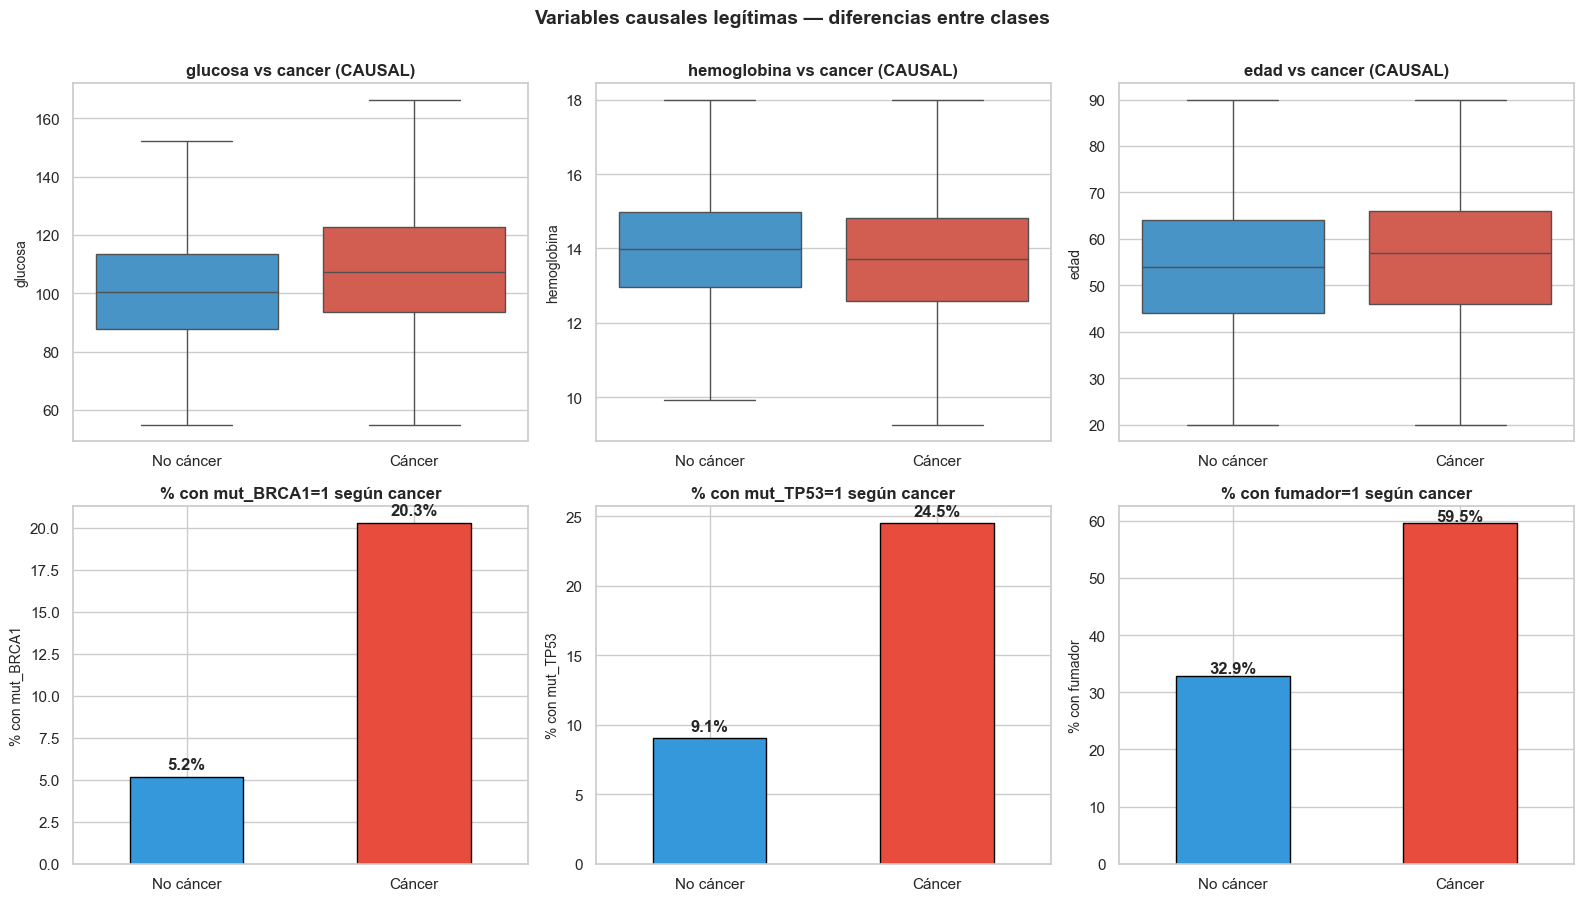


  COMPARATIVA: % con mutación según diagnóstico de cáncer
  mut_BRCA1    → No cáncer:  5.17%   Cáncer: 20.27%   lift: 3.92x
  mut_TP53     → No cáncer:  9.05%   Cáncer: 24.48%   lift: 2.70x
  mut_KRAS     → No cáncer: 10.24%   Cáncer: 24.42%   lift: 2.39x
  mut_EGFR     → No cáncer:  8.37%   Cáncer: 15.89%   lift: 1.90x
  mut_PIK3CA   → No cáncer:  8.04%   Cáncer: 12.94%   lift: 1.61x
  mut_ALK      → No cáncer:  4.92%   Cáncer:  4.89%   lift: 0.99x
  mut_BRAF     → No cáncer:  6.32%   Cáncer:  9.39%   lift: 1.49x
  fumador      → No cáncer: 32.88%   Cáncer: 59.54%   lift: 1.81x


In [14]:
# Variables que SÍ deben usarse (causales)
causal_vars_continuas = ["glucosa", "hemoglobina", "edad"]
causal_vars_binarias = ["mut_BRCA1", "mut_TP53", "fumador"]

# Reutilizamos la paleta y la columna cancer_str de la celda anterior
palette_target = {"0": "#3498db", "1": "#e74c3c"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Fila 1: continuas (boxplots)
for i, var in enumerate(causal_vars_continuas):
    sns.boxplot(data=df_master, x="cancer_str", y=var, hue="cancer_str",
                palette=palette_target, showfliers=False,
                ax=axes[0, i], legend=False)
    axes[0, i].set_title(f"{var} vs cancer (CAUSAL)", fontweight="bold")
    axes[0, i].set_xticklabels(["No cáncer", "Cáncer"])
    axes[0, i].set_xlabel("")

# Fila 2: binarias (% positivos por clase)
for i, var in enumerate(causal_vars_binarias):
    pct = df_master.groupby("cancer")[var].mean() * 100
    pct.plot(kind="bar", ax=axes[1, i],
             color=["#3498db", "#e74c3c"], edgecolor="black")
    axes[1, i].set_title(f"% con {var}=1 según cancer", fontweight="bold")
    axes[1, i].set_xticklabels(["No cáncer", "Cáncer"], rotation=0)
    axes[1, i].set_ylabel(f"% con {var}")
    axes[1, i].set_xlabel("")
    for j, v in enumerate(pct.values):
        axes[1, i].text(j, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Variables causales legítimas — diferencias entre clases",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_causales_visual.png", dpi=120, bbox_inches="tight")
plt.show()

# Tabla resumen
print("\n" + "=" * 70)
print("  COMPARATIVA: % con mutación según diagnóstico de cáncer")
print("=" * 70)
for var in ["mut_BRCA1", "mut_TP53", "mut_KRAS", "mut_EGFR", "mut_PIK3CA",
            "mut_ALK", "mut_BRAF", "fumador"]:
    pct_neg = df_master.loc[df_master["cancer"] == 0, var].mean() * 100
    pct_pos = df_master.loc[df_master["cancer"] == 1, var].mean() * 100
    lift = pct_pos / pct_neg if pct_neg > 0 else float("inf")
    print(f"  {var:12s} → No cáncer: {pct_neg:>5.2f}%   Cáncer: {pct_pos:>5.2f}%   lift: {lift:.2f}x")

## Análisis de las comorbilidades

  COMORBILIDADES — relación con cáncer
Variable                % en No-cáncer     % en Cáncer     Lift   ¿En metadata?
---------------------------------------------------------------------------
diabetes                       32.70%          41.85%     1.28x       no listada
hipertension                   41.88%          54.55%     1.30x             +0.5
obesidad                       30.80%          54.76%     1.78x             +1.1
enfermedad_cardiaca            16.39%          17.61%     1.07x       no listada
asma                            8.12%           8.33%     1.03x       no listada
epoc                            8.74%          11.01%     1.26x       no listada


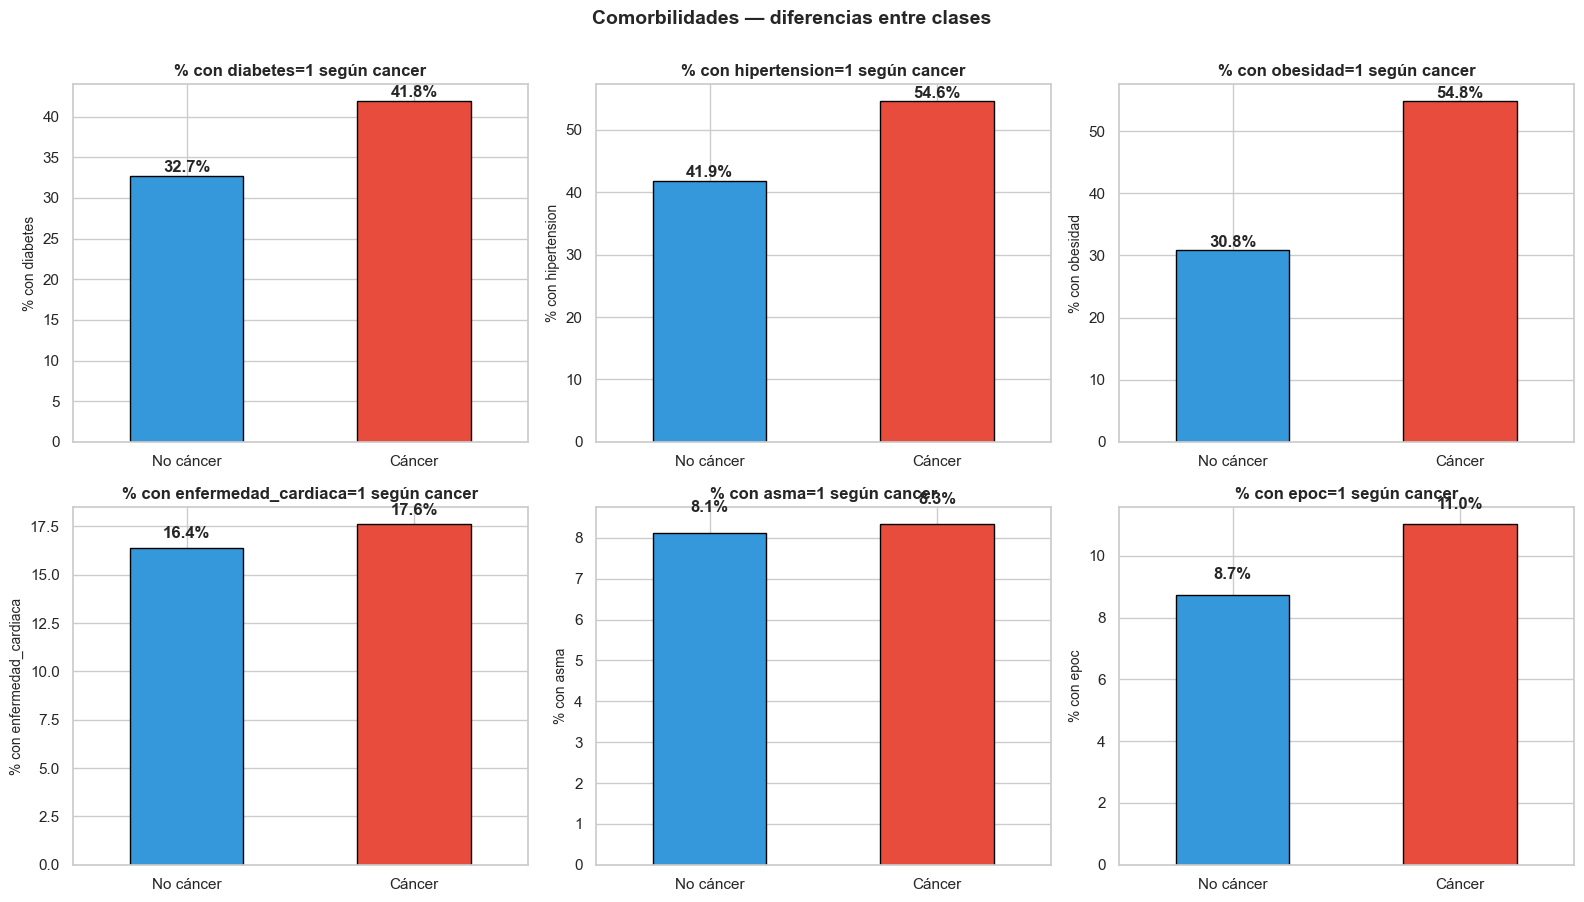

In [15]:
# === Comorbilidades: diabetes, hipertension, obesidad, enfermedad_cardiaca, asma, epoc ===
comorbilidades = ["diabetes", "hipertension", "obesidad", "enfermedad_cardiaca", "asma", "epoc"]

print("=" * 75)
print("  COMORBILIDADES — relación con cáncer")
print("=" * 75)
print(f"{'Variable':22s} {'% en No-cáncer':>15s} {'% en Cáncer':>15s} {'Lift':>8s} {'¿En metadata?':>15s}")
print("-" * 75)

# Pesos según el modelo generativo de la metadata
pesos_metadata = {
    "diabetes": "no listada",
    "hipertension": "+0.5",
    "obesidad": "+1.1",
    "enfermedad_cardiaca": "no listada",
    "asma": "no listada",
    "epoc": "no listada",
}

for var in comorbilidades:
    pct_neg = df_master.loc[df_master["cancer"] == 0, var].mean() * 100
    pct_pos = df_master.loc[df_master["cancer"] == 1, var].mean() * 100
    lift = pct_pos / pct_neg if pct_neg > 0 else float("inf")
    print(f"{var:22s} {pct_neg:>13.2f}%  {pct_pos:>13.2f}%  {lift:>7.2f}x  {pesos_metadata[var]:>15s}")

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(comorbilidades):
    pct = df_master.groupby("cancer")[var].mean() * 100
    pct.plot(kind="bar", ax=axes[i],
             color=["#3498db", "#e74c3c"], edgecolor="black")
    axes[i].set_title(f"% con {var}=1 según cancer", fontweight="bold")
    axes[i].set_xticklabels(["No cáncer", "Cáncer"], rotation=0)
    axes[i].set_ylabel(f"% con {var}")
    axes[i].set_xlabel("")
    for j, v in enumerate(pct.values):
        axes[i].text(j, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Comorbilidades — diferencias entre clases",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_comorbilidades.png", dpi=120, bbox_inches="tight")
plt.show()

## Análisis de variables sociodemográficas

  SOCIODEMOGRÁFICAS — relación con cáncer

Variables numéricas (medianas por clase):
  num_hijos                 → No cáncer mediana=1.00 media=1.50  |  Cáncer mediana=1.00 media=1.50
  distancia_hospital_km     → No cáncer mediana=17.00 media=24.85  |  Cáncer mediana=17.20 media=24.91


Variables categóricas (% de cáncer dentro de cada categoría):

  nivel_educativo:
       Sin estudios         → 19.73% cáncer  (n=  5109)
       Universitario        → 19.34% cáncer  (n= 12383)
       Secundaria           → 19.34% cáncer  (n= 19931)
       Primaria             → 18.98% cáncer  (n= 12578)

  nivel_ingresos:
       Medio                → 19.40% cáncer  (n= 19948)
       Muy bajo             → 19.33% cáncer  (n=  5975)
       Alto                 → 19.32% cáncer  (n=  9880)
       Bajo                 → 19.09% cáncer  (n= 14198)

  zona:
       Rural                → 19.45% cáncer  (n=  9944)
       Semiurbana           → 19.35% cáncer  (n= 12649)
       Urbana               → 19.20% cánc

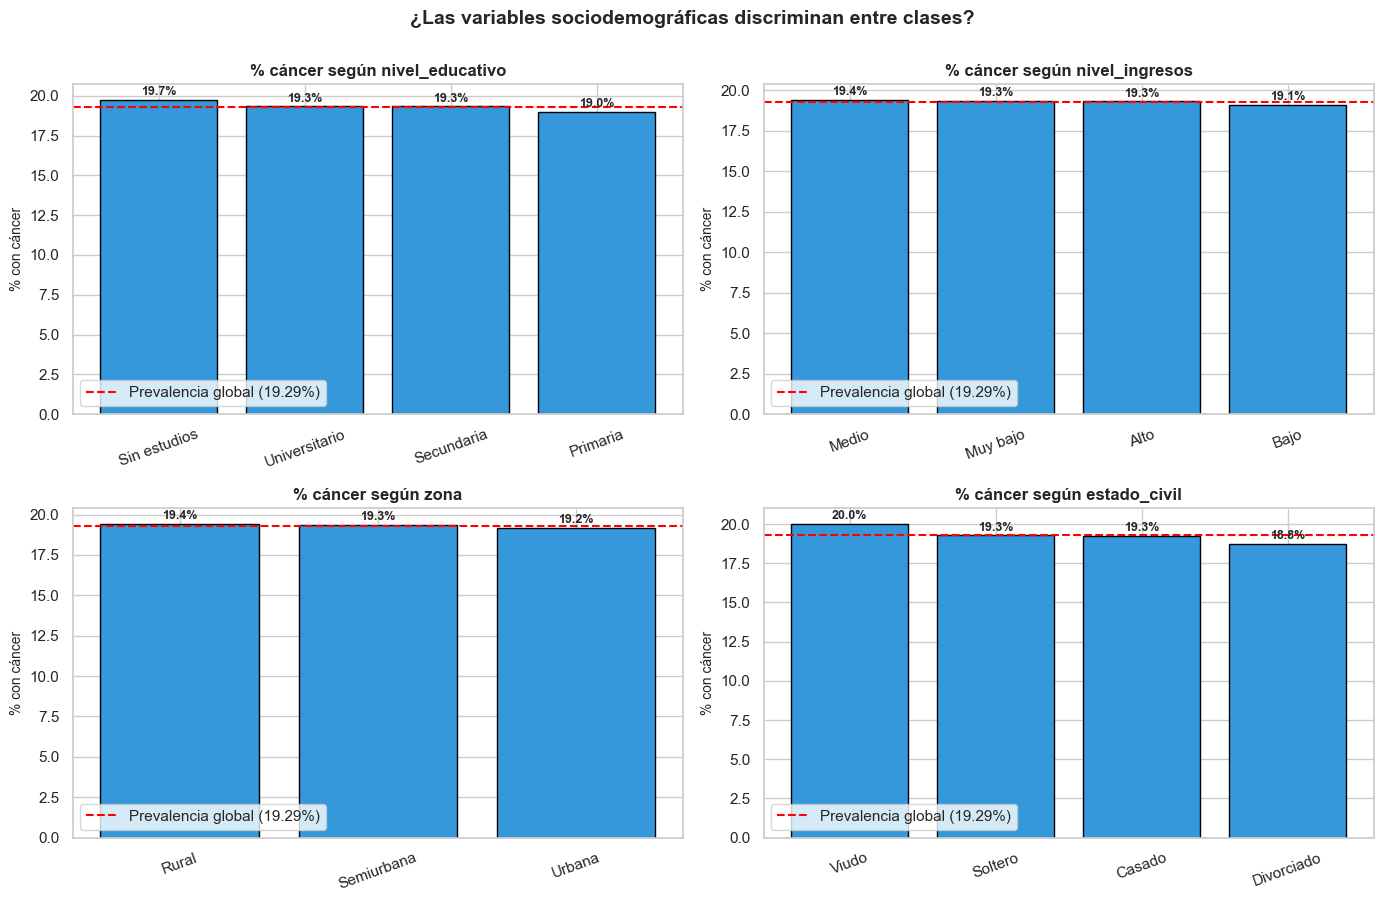

In [16]:
# === Variables sociodemográficas ===
print("=" * 75)
print("  SOCIODEMOGRÁFICAS — relación con cáncer")
print("=" * 75)

# Numéricas
num_demo = ["num_hijos", "distancia_hospital_km"]
print("\nVariables numéricas (medianas por clase):")
for var in num_demo:
    med_neg = df_master.loc[df_master["cancer"] == 0, var].median()
    med_pos = df_master.loc[df_master["cancer"] == 1, var].median()
    mean_neg = df_master.loc[df_master["cancer"] == 0, var].mean()
    mean_pos = df_master.loc[df_master["cancer"] == 1, var].mean()
    print(f"  {var:25s} → No cáncer mediana={med_neg:.2f} media={mean_neg:.2f}  |  Cáncer mediana={med_pos:.2f} media={mean_pos:.2f}")

# Categóricas: % de cáncer dentro de cada categoría
cat_demo = ["nivel_educativo", "nivel_ingresos", "zona", "estado_civil"]

print("\n\nVariables categóricas (% de cáncer dentro de cada categoría):")
for var in cat_demo:
    print(f"\n  {var}:")
    tasa = df_master.groupby(var)["cancer"].agg(["mean", "count"])
    tasa["mean_pct"] = tasa["mean"] * 100
    tasa = tasa.sort_values("mean_pct", ascending=False)
    for cat, row in tasa.iterrows():
        marker = "⚠️ " if abs(row["mean_pct"] - 19.29) > 2 else "   "
        print(f"    {marker}{cat:20s} → {row['mean_pct']:5.2f}% cáncer  (n={int(row['count']):>6})")

print("\n  (Recuerda: prevalencia global = 19.29%. Si todas las categorías están cerca,")
print("   la variable no discrimina y aporta poco al modelo.)")

# Visualización conjunta de las 4 categóricas
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, var in enumerate(cat_demo):
    tasa = df_master.groupby(var)["cancer"].mean() * 100
    tasa = tasa.sort_values(ascending=False)
    bars = axes[i].bar(tasa.index, tasa.values, edgecolor="black", color="#3498db")
    axes[i].axhline(y=19.29, color="red", linestyle="--", linewidth=1.5,
                    label="Prevalencia global (19.29%)")
    axes[i].set_title(f"% cáncer según {var}", fontweight="bold")
    axes[i].set_ylabel("% con cáncer")
    axes[i].legend()
    axes[i].tick_params(axis="x", rotation=20)
    for bar, v in zip(bars, tasa.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                     f"{v:.1f}%", ha="center", fontweight="bold", fontsize=9)

plt.suptitle("¿Las variables sociodemográficas discriminan entre clases?",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_sociodemograficas.png", dpi=120, bbox_inches="tight")
plt.show()

## Hipótesis: ¿actividad_fisica es protectora?

  ACTIVIDAD FÍSICA — efecto protector esperado

Categoría           % cáncer    n pacientes
---------------------------------------------
  Baja               24.02%       22,569
  Moderada           17.19%       17,392
  Alta               12.30%       10,040

Lectura esperada: % cáncer debe ser MENOR en 'Alta' que en 'Baja'
(según metadata: peso -1.2 para Alta, -0.6 para Moderada, 0 para Baja)


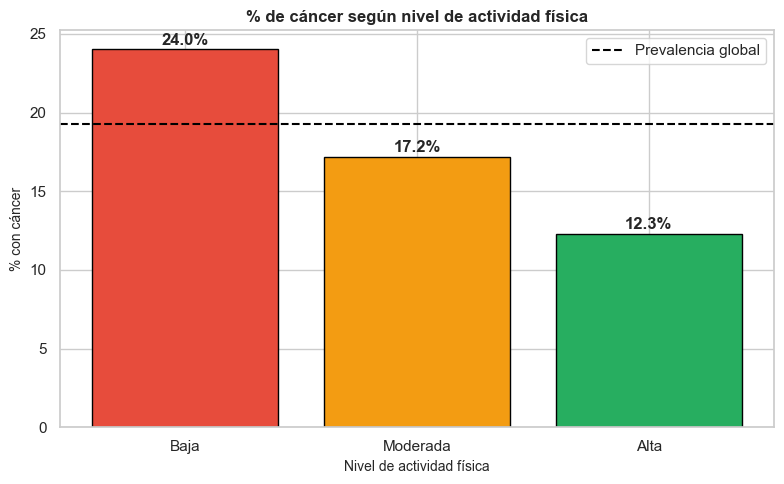

In [17]:
# === Verificación del efecto protector de actividad_fisica ===
print("=" * 60)
print("  ACTIVIDAD FÍSICA — efecto protector esperado")
print("=" * 60)

tasa_af = df_master.groupby("actividad_fisica")["cancer"].agg(["mean", "count"]).reset_index()
tasa_af["mean_pct"] = tasa_af["mean"] * 100
tasa_af = tasa_af.sort_values("mean_pct", ascending=False)

print(f"\n{'Categoría':15s} {'% cáncer':>12s} {'n pacientes':>14s}")
print("-" * 45)
for _, row in tasa_af.iterrows():
    print(f"  {row['actividad_fisica']:13s} {row['mean_pct']:>10.2f}%   {int(row['count']):>10,}")

print(f"\nLectura esperada: % cáncer debe ser MENOR en 'Alta' que en 'Baja'")
print(f"(según metadata: peso -1.2 para Alta, -0.6 para Moderada, 0 para Baja)")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
orden = ["Baja", "Moderada", "Alta"]
tasa_ordenada = df_master.groupby("actividad_fisica")["cancer"].mean().reindex(orden) * 100
bars = ax.bar(orden, tasa_ordenada.values,
              color=["#e74c3c", "#f39c12", "#27ae60"], edgecolor="black")
ax.axhline(y=19.29, color="black", linestyle="--", linewidth=1.5,
           label="Prevalencia global")
ax.set_title("% de cáncer según nivel de actividad física", fontweight="bold")
ax.set_ylabel("% con cáncer")
ax.set_xlabel("Nivel de actividad física")
ax.legend()
for bar, v in zip(bars, tasa_ordenada.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_actividad_fisica.png", dpi=120, bbox_inches="tight")
plt.show()

## Construcción del feature_set definitivo

In [18]:
# === FEATURE SET FINAL DEFINITIVO ===

# Features que SÍ entran al pipeline (20 en total)
FEATURES_BIOQUIMICAS = ["glucosa", "colesterol", "trigliceridos", "hemoglobina",
                        "leucocitos", "plaquetas", "creatinina"]

FEATURES_GENETICAS = ["mut_BRCA1", "mut_TP53", "mut_EGFR", "mut_KRAS",
                      "mut_PIK3CA", "mut_ALK", "mut_BRAF"]

FEATURES_CLINICAS = ["diabetes", "hipertension", "obesidad", "epoc"]

FEATURES_HABITOS = ["fumador", "actividad_fisica"]   # actividad_fisica → ordinal

FEATURES_DEMO = ["edad"]

FEATURES_FINALES = (FEATURES_BIOQUIMICAS + FEATURES_GENETICAS +
                    FEATURES_CLINICAS + FEATURES_HABITOS + FEATURES_DEMO)

TARGET = "cancer"

# Variables descartadas (para documentación)
EXCLUIDAS_LEAKAGE = ["coste_total", "coste_farmaco", "num_ingresos",
                     "dias_hospital", "tipo_seguro", "vive"]
EXCLUIDAS_CONSTANTE = ["alcohol"]
EXCLUIDAS_RUIDO = ["enfermedad_cardiaca", "asma"]
EXCLUIDAS_SIN_SENAL = ["nivel_educativo", "nivel_ingresos", "zona",
                       "estado_civil", "num_hijos", "distancia_hospital_km"]

# Verificación
print(f"Features finales:        {len(FEATURES_FINALES)}")
print(f"  Bioquímicas:           {len(FEATURES_BIOQUIMICAS)}")
print(f"  Genéticas:             {len(FEATURES_GENETICAS)}")
print(f"  Clínicas:              {len(FEATURES_CLINICAS)}")
print(f"  Hábitos:               {len(FEATURES_HABITOS)}")
print(f"  Demográficas:          {len(FEATURES_DEMO)}")
print()
print(f"Variables excluidas:     {len(EXCLUIDAS_LEAKAGE) + len(EXCLUIDAS_CONSTANTE) + len(EXCLUIDAS_RUIDO) + len(EXCLUIDAS_SIN_SENAL)}")
print(f"  Por leakage:           {len(EXCLUIDAS_LEAKAGE)}")
print(f"  Por ser constante:     {len(EXCLUIDAS_CONSTANTE)}")
print(f"  Por ser ruido:         {len(EXCLUIDAS_RUIDO)}")
print(f"  Sin señal predictiva:  {len(EXCLUIDAS_SIN_SENAL)}")
print()
print(f"Total variables original (sin paciente_id ni cancer): {len(FEATURES_FINALES) + 14}")
print(f"Variable objetivo: '{TARGET}'")

# Vamos a crear una versión 'workable' del df con las 20 features ya codificadas
# para los gráficos de correlación (la transformación oficial vendrá en Fase 2)
df_corr = df_master[FEATURES_FINALES + [TARGET]].copy()

# Codificación ordinal de actividad_fisica
mapeo_actividad = {"Baja": 0, "Moderada": 1, "Alta": 2}
df_corr["actividad_fisica"] = df_corr["actividad_fisica"].map(mapeo_actividad)

print(f"\nDataFrame para correlaciones: {df_corr.shape}")
print(f"Tipos: {df_corr.dtypes.value_counts().to_dict()}")

Features finales:        21
  Bioquímicas:           7
  Genéticas:             7
  Clínicas:              4
  Hábitos:               2
  Demográficas:          1

Variables excluidas:     15
  Por leakage:           6
  Por ser constante:     1
  Por ser ruido:         2
  Sin señal predictiva:  6

Total variables original (sin paciente_id ni cancer): 35
Variable objetivo: 'cancer'

DataFrame para correlaciones: (50001, 22)
Tipos: {dtype('int64'): 15, dtype('float64'): 7}


## Correlaciones con la variable objetivo (ranking)

  CORRELACIÓN DE CADA FEATURE CON 'cancer'

Feature                    Correlación
----------------------------------------
mut_BRCA1                 +    0.2186  █████████████████████
fumador                   +    0.2167  █████████████████████
obesidad                  +    0.1977  ███████████████████
mut_TP53                  +    0.1871  ██████████████████
mut_KRAS                  +    0.1665  ████████████████
glucosa                   +    0.1511  ███████████████
trigliceridos             +    0.1086  ██████████
hipertension              +    0.1007  ██████████
mut_EGFR                  +    0.0996  █████████
leucocitos                +    0.0983  █████████
colesterol                +    0.0874  ████████
diabetes                  +    0.0760  ███████
mut_PIK3CA                +    0.0676  ██████
edad                      +    0.0542  █████
mut_BRAF                  +    0.0478  ████
epoc                      +    0.0310  ███
mut_ALK                   -    0.0005  
creatinina     

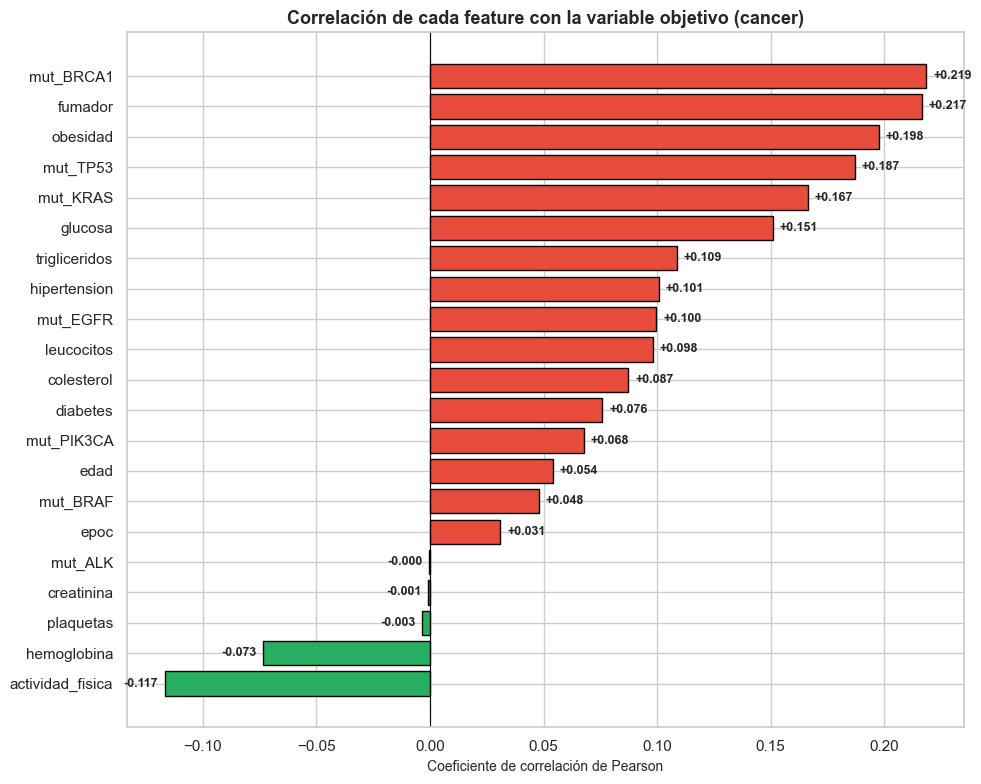

In [19]:
# === Correlación de cada feature con la variable objetivo ===
correlations = df_corr.corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print("=" * 60)
print("  CORRELACIÓN DE CADA FEATURE CON 'cancer'")
print("=" * 60)
print(f"\n{'Feature':25s} {'Correlación':>12s}")
print("-" * 40)
for feat, corr in correlations.items():
    bar_len = int(abs(corr) * 100)
    bar = "█" * bar_len
    sign = "+" if corr > 0 else "-"
    print(f"{feat:25s} {sign}{abs(corr):>10.4f}  {bar}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#27ae60" if c < 0 else "#e74c3c" for c in correlations.values]
bars = ax.barh(correlations.index, correlations.values, color=colors, edgecolor="black")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada feature con la variable objetivo (cancer)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Coeficiente de correlación de Pearson")
ax.invert_yaxis()
for bar, v in zip(bars, correlations.values):
    label_x = v + (0.003 if v > 0 else -0.003)
    ha = "left" if v > 0 else "right"
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f"{v:+.3f}", va="center", ha=ha, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_correlaciones_target.png", dpi=120, bbox_inches="tight")
plt.show()

## Heatmap de correlaciones entre features (multicolinealidad)

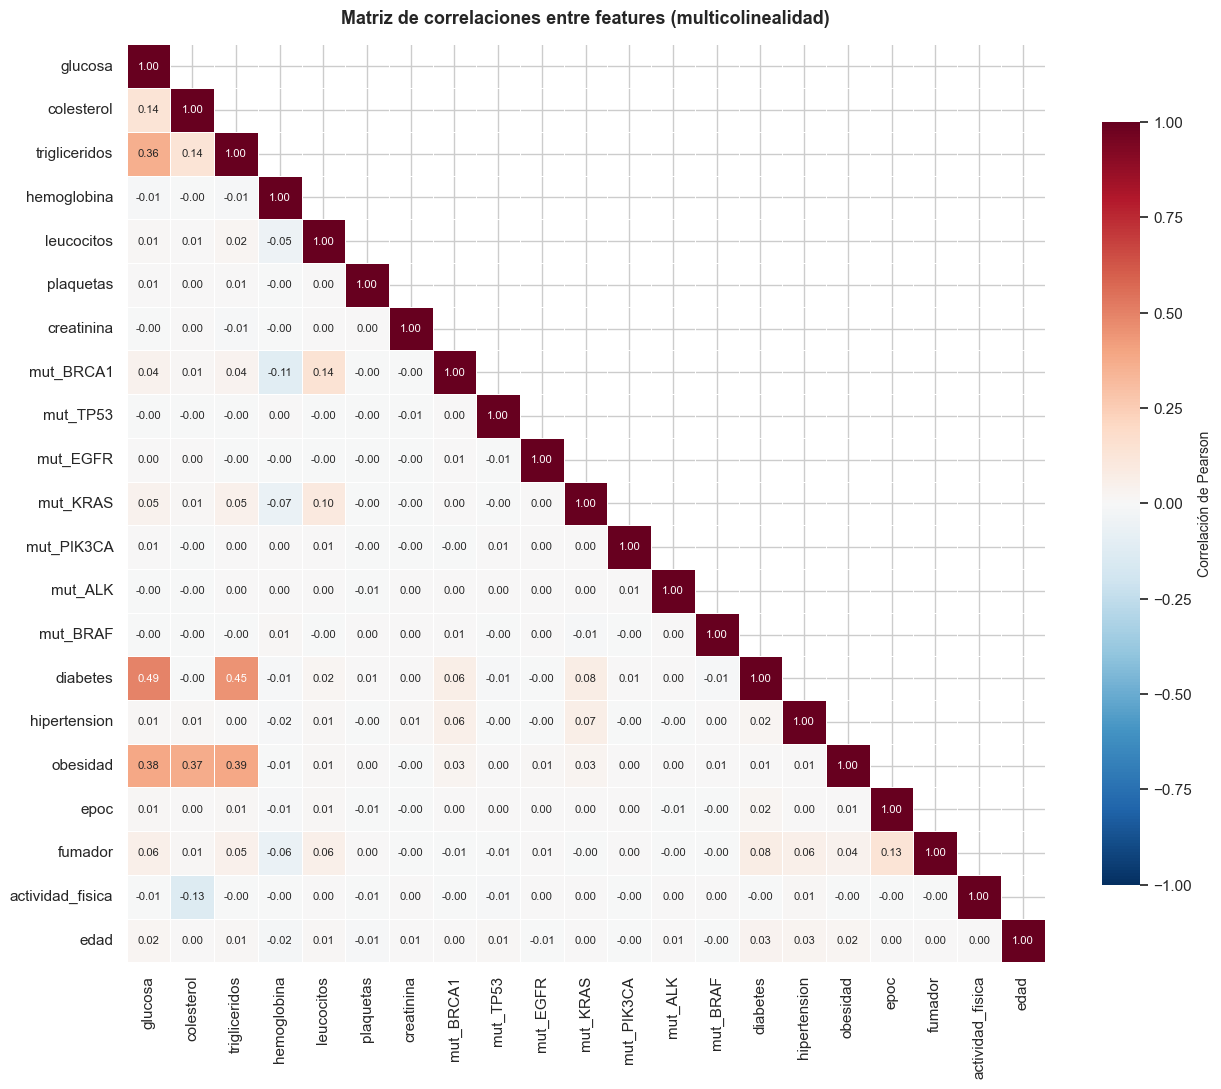


  PARES DE FEATURES CON CORRELACIÓN ALTA (|r| > 0.3)
  glucosa               ↔  diabetes              →  r = +0.495
  trigliceridos         ↔  diabetes              →  r = +0.446
  trigliceridos         ↔  obesidad              →  r = +0.389
  glucosa               ↔  obesidad              →  r = +0.383
  colesterol            ↔  obesidad              →  r = +0.370
  glucosa               ↔  trigliceridos         →  r = +0.365


In [20]:
# === Matriz de correlaciones entre features (sin el target) ===
corr_matrix = df_corr[FEATURES_FINALES].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # ocultamos triangular superior
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"},
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Matriz de correlaciones entre features (multicolinealidad)",
             fontweight="bold", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_heatmap_features.png", dpi=120, bbox_inches="tight")
plt.show()

# Detectar pares con correlación alta (|r| > 0.5) que indicarían redundancia
print("\n" + "=" * 60)
print("  PARES DE FEATURES CON CORRELACIÓN ALTA (|r| > 0.3)")
print("=" * 60)
pares_altos = []
for i in range(len(FEATURES_FINALES)):
    for j in range(i+1, len(FEATURES_FINALES)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            pares_altos.append((FEATURES_FINALES[i], FEATURES_FINALES[j], r))

if pares_altos:
    for f1, f2, r in sorted(pares_altos, key=lambda x: -abs(x[2])):
        print(f"  {f1:20s}  ↔  {f2:20s}  →  r = {r:+.3f}")
else:
    print("  Ningún par con correlación |r| > 0.3.")
    print("  Las features son razonablemente independientes entre sí.")

## Guardar el resumen del EDA

In [21]:
# === Persistir el resumen del EDA para reutilizar en Fase 2 ===
import json

eda_summary = {
    "n_total": int(len(df_master)),
    "n_positivos": int((df_master["cancer"] == 1).sum()),
    "n_negativos": int((df_master["cancer"] == 0).sum()),
    "prevalencia": round(float((df_master["cancer"] == 1).mean()), 4),
    "ratio_desbalance": round(float((df_master["cancer"] == 0).sum() / (df_master["cancer"] == 1).sum()), 2),
    "features_finales": FEATURES_FINALES,
    "n_features_finales": len(FEATURES_FINALES),
    "target": TARGET,
    "excluidas": {
        "leakage": EXCLUIDAS_LEAKAGE,
        "constante": EXCLUIDAS_CONSTANTE,
        "ruido": EXCLUIDAS_RUIDO,
        "sin_senal": EXCLUIDAS_SIN_SENAL,
    },
    "mapeo_actividad_fisica": {"Baja": 0, "Moderada": 1, "Alta": 2},
}

# Guardamos en docs/ porque es documentación
output_path = PROJECT_ROOT / "docs" / "eda_summary.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, indent=2, ensure_ascii=False)

print(f"Resumen del EDA guardado en: {output_path}")
print(f"\nContenido:")
print(json.dumps(eda_summary, indent=2, ensure_ascii=False))

Resumen del EDA guardado en: c:\Users\alvar\Desktop\proyecto-cancer-ia\docs\eda_summary.json

Contenido:
{
  "n_total": 50001,
  "n_positivos": 9644,
  "n_negativos": 40357,
  "prevalencia": 0.1929,
  "ratio_desbalance": 4.18,
  "features_finales": [
    "glucosa",
    "colesterol",
    "trigliceridos",
    "hemoglobina",
    "leucocitos",
    "plaquetas",
    "creatinina",
    "mut_BRCA1",
    "mut_TP53",
    "mut_EGFR",
    "mut_KRAS",
    "mut_PIK3CA",
    "mut_ALK",
    "mut_BRAF",
    "diabetes",
    "hipertension",
    "obesidad",
    "epoc",
    "fumador",
    "actividad_fisica",
    "edad"
  ],
  "n_features_finales": 21,
  "target": "cancer",
  "excluidas": {
    "leakage": [
      "coste_total",
      "coste_farmaco",
      "num_ingresos",
      "dias_hospital",
      "tipo_seguro",
      "vive"
    ],
    "constante": [
      "alcohol"
    ],
    "ruido": [
      "enfermedad_cardiaca",
      "asma"
    ],
    "sin_senal": [
      "nivel_educativo",
      "nivel_ingresos",
  